In [8]:
import sys
from pathlib import Path

PROJECT_ROOT = Path().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

import matplotlib.pyplot as plt
from src.data_loader import load_data
train, features, stores = load_data()

1. Total sales over time

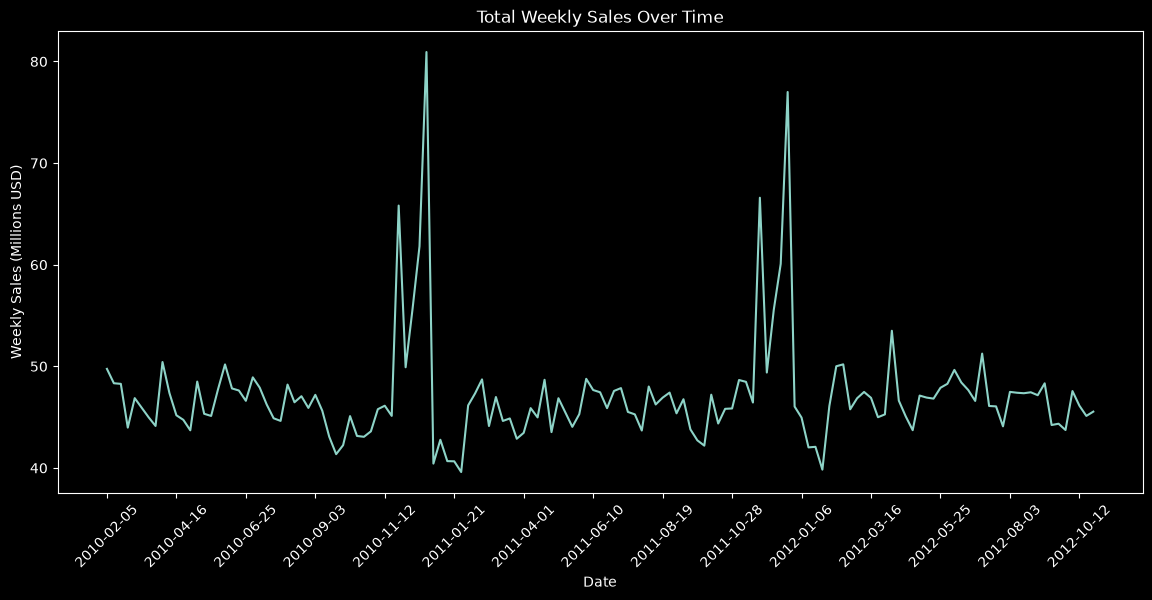

In [9]:
weekly_sales = train.groupby('Date')['Weekly_Sales'].sum()
plt.figure(figsize=(14,6))
weekly_sales = weekly_sales / 1e6
plt.plot(weekly_sales)
plt.title("Total Weekly Sales Over Time")
plt.xticks(weekly_sales.index[::10], rotation=45)
plt.xlabel("Date")
plt.ylabel("Weekly Sales (Millions USD)")
plt.show()

- Total weekly sales show a clear fluctuating pattern over time.
- There is no strong long-term upward trend, but recurring peaks and dips are visible.
- This suggests that demand is highly influenced by seasonality rather than steady growth.
- Several sharp spikes indicate possible holiday or promotional effects.

2. Holiday Impact

In [12]:
holiday_sales = train.groupby('IsHoliday')['Weekly_Sales'].mean()
print(holiday_sales)

IsHoliday
False    15901.445069
True     17035.823187
Name: Weekly_Sales, dtype: float64


- On average, holiday sales are approximately 7% higher than non-holiday sales. We can conclude that holidays increase demand.

3. Store Performance

Store
20    301.397792
4     299.543953
14    288.999911
13    286.517704
2     275.382441
10    271.617714
27    253.855917
6     223.756131
1     222.402809
39    207.445542
19    206.634862
31    199.613905
23    198.750618
24    194.016021
11    193.962787
28    189.263681
41    181.341935
32    166.819246
18    155.114734
22    147.075649
12    144.287230
26    143.416394
34    138.249763
40    137.870310
35    131.520672
8     129.951181
17    127.782139
45    112.395341
21    108.117879
25    101.061179
43     90.565435
15     89.133684
7      81.598275
42     79.565752
9      77.789219
29     77.141554
16     74.252425
37     74.202740
30     62.716885
3      57.586735
38     55.159626
36     53.412215
5      45.475689
44     43.293088
33     37.160222
Name: Weekly_Sales, dtype: float64


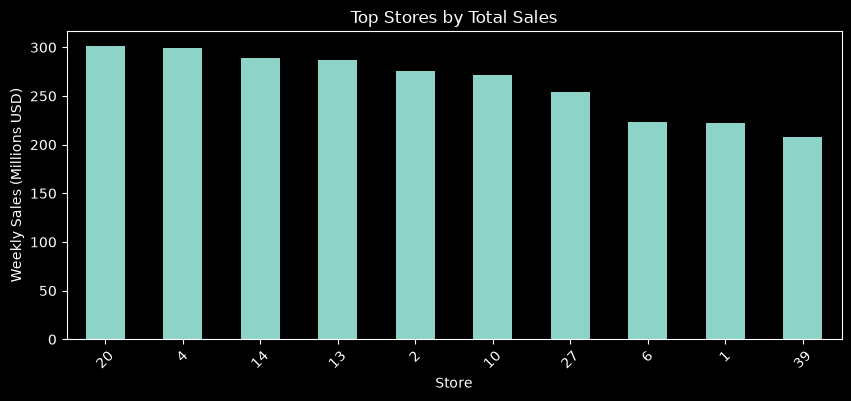

In [17]:
store_sales = train.groupby('Store')['Weekly_Sales'].sum().sort_values(ascending=False)
store_sales = store_sales/1e6
print(store_sales)
store_sales.head(10).plot(kind='bar',figsize=(10,4))
plt.title("Top Stores by Total Sales")
plt.xlabel('Store')
plt.ylabel('Weekly Sales (Millions USD)')
plt.xticks(rotation=45)
plt.show()

- Sales distribution across stores is highly uneven.
- A small number of stores contribute disproportionately to total revenue.

4. Department Analysis

Dept
92    75204.870531
95    69824.423080
38    61090.619568
72    50566.515417
65    45441.706224
          ...     
51       21.931729
39       11.123750
78        7.296638
43        1.193333
47       -7.682554
Name: Weekly_Sales, Length: 81, dtype: float64


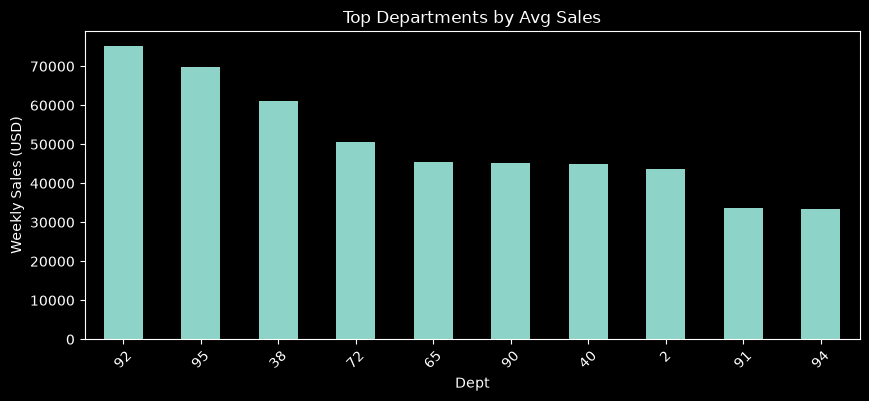

In [21]:
dept_sales = train.groupby('Dept')['Weekly_Sales'].mean().sort_values(ascending=False)
print(dept_sales)
dept_sales.head(10).plot(kind='bar',figsize=(10,4))
plt.title("Top Departments by Avg Sales")
plt.xlabel('Dept')
plt.ylabel('Weekly Sales (USD)')
plt.xticks(rotation=45)
plt.show()

- Weekly sales vary significantly across departments.
- A small number of departments contribute disproportionately to total sales.

5. Sales Distribution

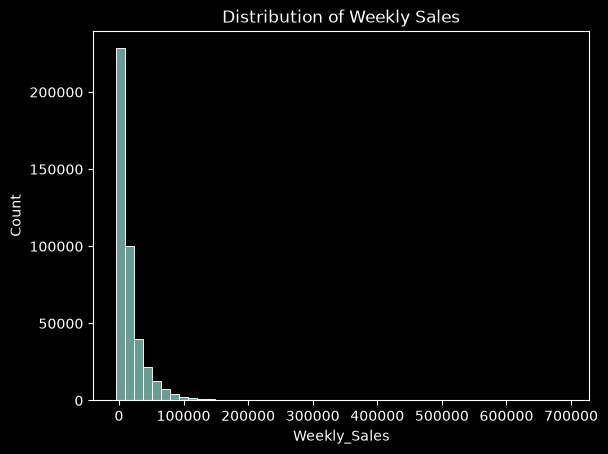

In [22]:
import seaborn as sns
sns.histplot(train['Weekly_Sales'], bins=50)
plt.title("Distribution of Weekly Sales")
plt.show()

- Weekly sales distribution is right-skewed, with a small number of very high values.
- This indicates the presence of outliers or high-performing events.

6. Seasonality Check

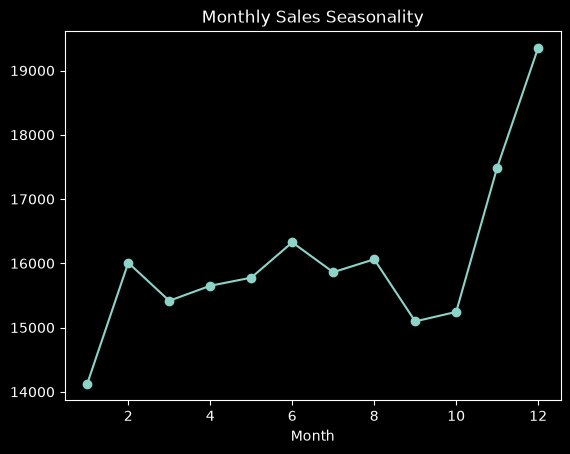

In [26]:
import pandas as pd

train['Date'] = pd.to_datetime(train['Date'])
train['Month'] = train['Date'].dt.month
monthly_sales = train.groupby('Month')['Weekly_Sales'].mean()
monthly_sales.plot(kind='line', marker='o')
plt.title("Monthly Sales Seasonality")
plt.show()

- Monthly sales show variation across different periods of the year.
- Certain months consistently have higher average demand (November, December).
- This confirms the presence of seasonality in the dataset.

In [28]:
print(train.groupby(['Dept', 'Month'])['Weekly_Sales'].mean())

Dept  Month
1     1        13665.363194
      2        23439.498833
      3        18478.219556
      4        27969.288698
      5        14168.030111
                   ...     
99    8          129.769379
      9           54.817528
      10         253.057222
      11        2301.604118
      12        1836.538313
Name: Weekly_Sales, Length: 962, dtype: float64


#Conclusion
- Demand forecasting for Walmart shows strong seasonality and holiday effects.
- Sales behavior varies significantly across stores and departments.
- The distribution of sales is skewed, suggesting the need for robust modeling techniques.
- These insights will guide feature engineering (lag features, rolling statistics, time-based features).